## Лабораторная 3

**Изучить и реализовать MLP (многослойная искусственная нейронная сеть) для классификации нелинейно разделимых данных.**

1. Сгенерируйте данные (любым методом из sklearn.datasets).
2. Визуализируйте данные на плоскости.
3. Создайте MLP: вход (2 нейрона), скрытый слой (4 нейрона, ReLU), выход (1 нейрон, sigmoid) - можете использовать pytorch / keras
4. Разделите данные (80% — обучение, 20% — тест).
5. Обучите на 1000 эпох, постройте график потерь.
6. Оцените точность на тесте.
7. * *Если увлеклись, можно реализовать MLP для решения XOR.*


In [1]:
import numpy as np
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from tensorflow import keras
from matplotlib import pyplot as plt

# Генерируем данные методом make_circles

In [5]:
x, y = make_circles(1000, noise=0.1, random_state=1234, factor=0.6)
y = y.reshape(-1, 1)

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

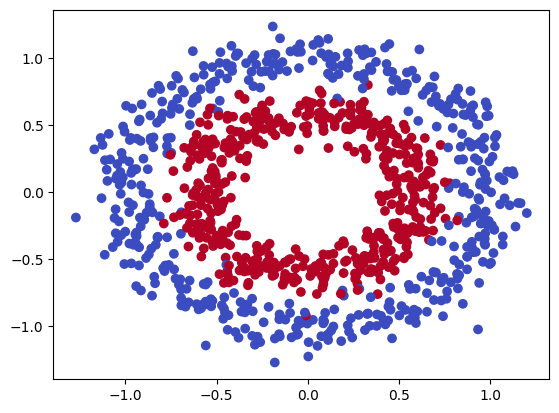

In [7]:
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='coolwarm')
plt.show()

# Обучаем модель для задачи make_circles

In [8]:
model = keras.models.Sequential([
    keras.layers.Input((2, )),
    keras.layers.Dense(4, activation='sigmoid'),
    keras.layers.Dense(1, activation='sigmoid')
])

In [9]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [10]:
history = model.fit(x_train, y_train, epochs=1000, batch_size=50)

Epoch 1/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4944 - loss: 0.7012
Epoch 2/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4565 - loss: 0.6930 
Epoch 3/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4463 - loss: 0.6958 
Epoch 4/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3918 - loss: 0.6957 
Epoch 5/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3963 - loss: 0.6954 
Epoch 6/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4008 - loss: 0.6934 
Epoch 7/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4598 - loss: 0.6921 
Epoch 8/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4555 - loss: 0.6922 
Epoch 9/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3992 - loss: 0.6928 
Epoch 10/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4378 - loss: 0.6927 
Epoch 11/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5199 - loss: 0.6920  
Epoch 12/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 

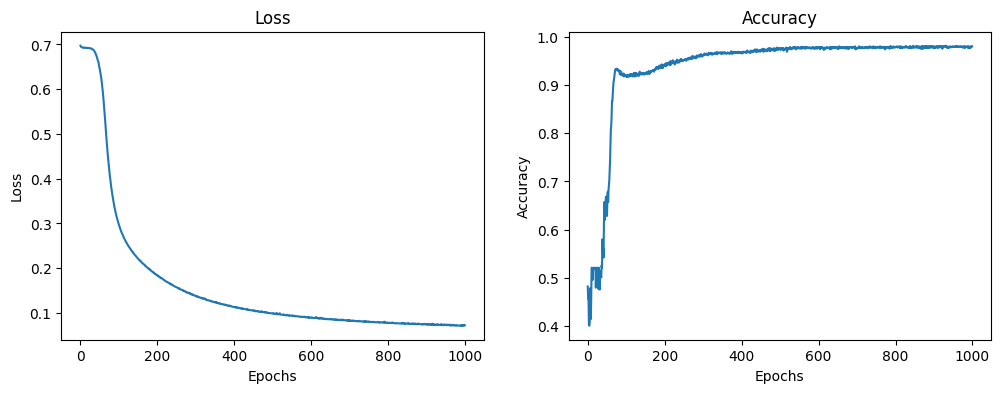

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Training Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')

ax2.plot(history.history['accuracy'], label='Training Accuracy')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')

plt.show()

In [12]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Binary accuracy на тестовой выборке составила {test_acc:.4f}.")

Binary accuracy на тестовой выборке составила 0.9700.


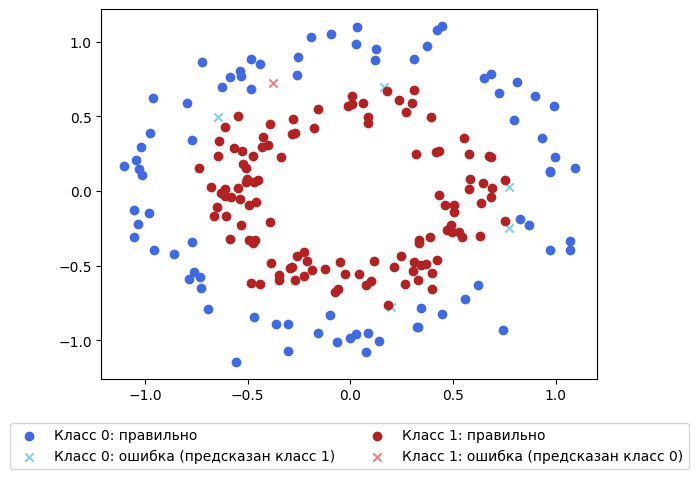

In [13]:
y_pred = model.predict(x_test, verbose=0)
labels_pred = y_pred.round()

correct_class0 = (y_test == 0) & (labels_pred == 0) 
incorrect_class0 = (y_test == 0) & (labels_pred == 1)
correct_class1 = (y_test == 1) & (labels_pred == 1)
incorrect_class1 = (y_test == 1) & (labels_pred == 0)

plt.scatter(x_test[correct_class0[:, 0], 0], x_test[correct_class0[:, 0], 1],
            c='royalblue', label='Класс 0: правильно')

plt.scatter(x_test[incorrect_class0[:, 0], 0], x_test[incorrect_class0[:, 0], 1],
            c='skyblue', marker='x', label='Класс 0: ошибка (предсказан класс 1)')

plt.scatter(x_test[correct_class1[:, 0], 0], x_test[correct_class1[:, 0], 1],
            c='firebrick', label='Класс 1: правильно')

plt.scatter(x_test[incorrect_class1[:, 0], 0], x_test[incorrect_class1[:, 0], 1],
            c='lightcoral', marker='x', label='Класс 1: ошибка (предсказан класс 0)')

plt.legend(bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=2)
plt.show()

# Генерируем данные для задачи XOR

In [14]:
x = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])
y = y.reshape(-1, 1)

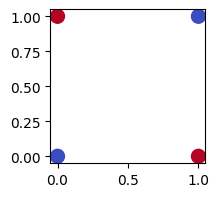

In [15]:
plt.figure(figsize=(2, 2))
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='coolwarm', s=100)
plt.show()

# Обучаем модель для задачи XOR

In [16]:
model = keras.models.Sequential([
    keras.layers.Input((2, )),
    keras.layers.Dense(4, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

In [17]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [18]:
history = model.fit(x, y, epochs=100, batch_size=1)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6333 - loss: 0.6655
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6333 - loss: 0.6375
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3667 - loss: 0.6957    
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4333 - loss: 0.6759    
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8333 - loss: 0.6526
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7333 - loss: 0.6550
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.6492
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.6321
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.5975 
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.6473
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.6466
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.

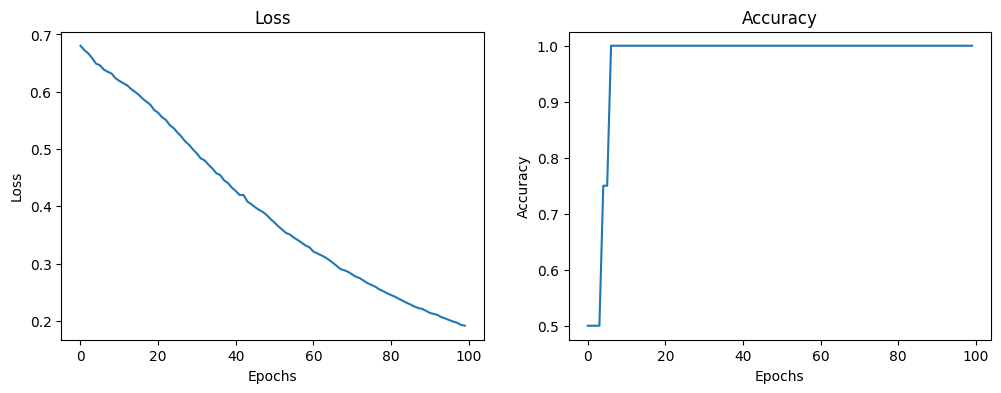

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Training Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')

ax2.plot(history.history['accuracy'], label='Training Accuracy')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')

plt.show()

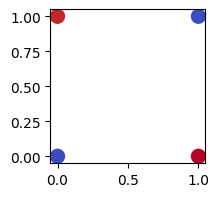

In [20]:
y_pred = model.predict(x, verbose=0)
plt.figure(figsize=(2, 2))
plt.scatter(x[:, 0], x[:, 1], c=y_pred, cmap='coolwarm', s=100)
plt.show()